## Random Forest mit optimierten Hyperparametern für Hotel-Bookings-Datensatz

Erstellung und Optimierung eines Random Forest Modells mit dem Hotel-Bookings-Datensatz:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

# Datensatz laden
df = pd.read_csv('/Users/danielmini/Projekte/data_mining_dsba/data/processed/hotel_bookings_processed.csv')

# Nicht verwendete Spalten entfernen
notinuse_col = ['reservation_status_date',
               'arrival_date_year',
               'arrival_date_month',
               'arrival_date_week_number', 
               'assigned_room_type',
               'reservation_status', 
               'arrival_date_day_of_month']

df = df.drop(columns=notinuse_col)

# Fehlende Werte behandeln
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].median())



# Gesamtdauer des Aufenthalts
df['total_stay_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
# Gesamtanzahl der Gäste
df['total_guests'] = df['adults'] + df['children'].fillna(0) + df['babies'].fillna(0)
# Flexibilitätsindex = Vorlaufzeit / Aufenthaltsdauer
df['flexibility_index'] = df['lead_time'] / (df['total_stay_nights'] + 0.1)  # +1 to avoid division by zero

# Spalten für die Modellierung auswählen
# Features und Ziel definieren (wir nehmen an, dass "is_canceled" vorhergesagt werden soll)
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']


In [13]:
# Kategorische und numerische Spalten identifizieren
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Statistische Zusammenfassung für numerische Spalten
if len(num_cols) > 0:
    print("\nStatistische Zusammenfassung numerischer Spalten:")
    display(df[num_cols].describe().T)


Statistische Zusammenfassung numerischer Spalten:


,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.011416,106.863097,0.00,18.000000,69.000,160.000000,737.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.000000,1.000,2.000000,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.000000,2.000,3.000000,50.0
adults,119390.0,1.856403,0.579261,0.00,2.000000,2.000,2.000000,55.0
children,119390.0,0.103886,0.398555,0.00,0.000000,0.000,0.000000,10.0
babies,119390.0,0.007949,0.097436,0.00,0.000000,0.000,0.000000,10.0
is_repeated_guest,119390.0,0.031912,0.175767,0.00,0.000000,0.000,0.000000,1.0
previous_cancellations,119390.0,0.087118,0.844336,0.00,0.000000,0.000,0.000000,26.0
previous_bookings_not_canceled,119390.0,0.137097,1.497437,0.00,0.000000,0.000,0.000000,72.0
booking_changes,119390.0,0.221124,0.652306,0.00,0.000000,0.000,0.000000,21.0


In [14]:
# Daten aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Präprozessor erstellen
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# Daten vorverarbeiten
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Hyperparameter-Grid definieren
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


In [15]:

# Random Forest initialisieren
rf = RandomForestClassifier(random_state=42)

# Hyperparameter-Suche durchführen
print("Hyperparameter-Optimierung läuft...")
search = RandomizedSearchCV(
    rf, param_grid, n_iter=20, cv=3, scoring='accuracy',
    n_jobs=-1, verbose=1, random_state=42
)

# Modell trainieren
search.fit(X_train_processed, y_train)

# Beste Hyperparameter ausgeben
best_params = search.best_params_
print("\nBeste Parameter:", best_params)
print("Beste Cross-Validation Score:", search.best_score_)

# Finales Modell mit optimalen Hyperparametern erstellen
final_model = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    random_state=42
)

# Finales Modell trainieren
final_model.fit(X_train_processed, y_train)

# Vorhersagen auf Testdaten
y_pred = final_model.predict(X_test_processed)


Hyperparameter-Optimierung läuft...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Beste Parameter: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
Beste Cross-Validation Score: 0.8767903533352372


In [16]:
# Beste Hyperparameter ausgeben
best_params = search.best_params_
print("\nBeste Parameter:", best_params)
print("Beste Cross-Validation Score:", search.best_score_)


Beste Parameter: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
Beste Cross-Validation Score: 0.8767903533352372



Test-Genauigkeit: 0.8854175391573834

Klassifikationsbericht:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     14907
           1       0.89      0.79      0.84      8971

    accuracy                           0.89     23878
   macro avg       0.89      0.87      0.87     23878
weighted avg       0.89      0.89      0.88     23878



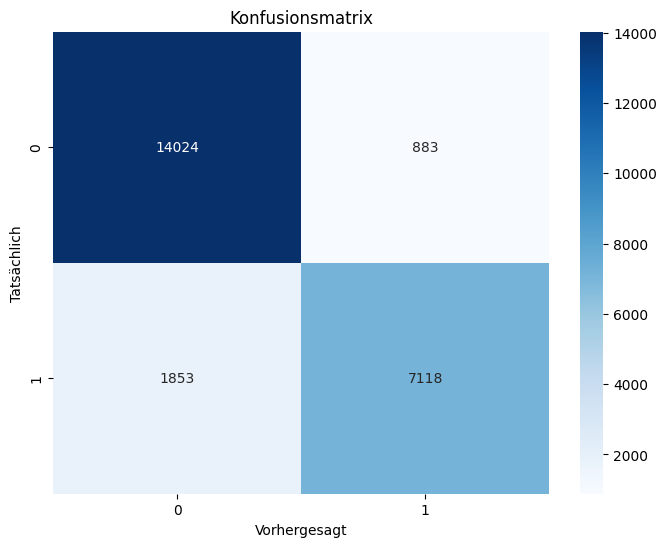

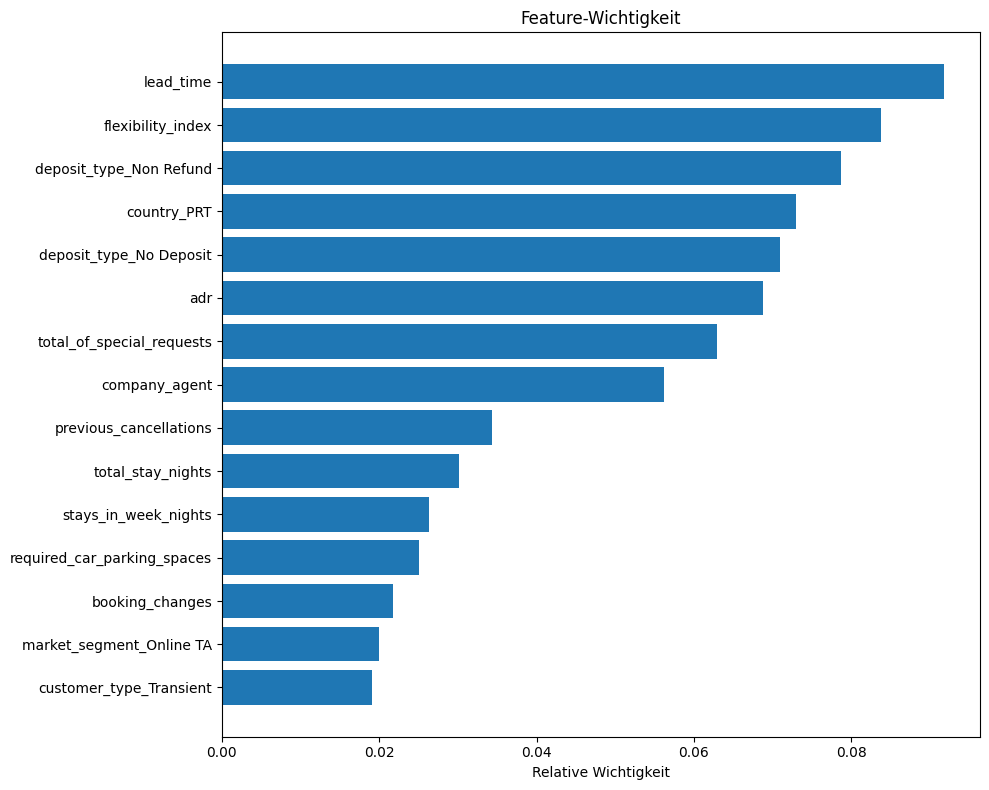


Beste Hyperparameter:
           Parameter  Wert
0       n_estimators   300
1  min_samples_split     2
2   min_samples_leaf     1
3       max_features  sqrt
4          max_depth    30


In [17]:
# Modell evaluieren
print("\nTest-Genauigkeit:", accuracy_score(y_test, y_pred))
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred))

# Konfusionsmatrix anzeigen
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Konfusionsmatrix')
plt.ylabel('Tatsächlich')
plt.xlabel('Vorhergesagt')
plt.show()

# Feature-Namen nach Vorverarbeitung erstellen
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
feature_names = np.concatenate([num_cols, cat_feature_names])

# Feature-Importance darstellen
importances = final_model.feature_importances_
indices = np.argsort(importances)[-15:]  # Top 15 Features

plt.figure(figsize=(10, 8))
plt.title('Feature-Wichtigkeit')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Wichtigkeit')
plt.tight_layout()
plt.show()

# DataFrame mit den besten Hyperparametern erstellen
best_params_df = pd.DataFrame({
    'Parameter': list(best_params.keys()),
    'Wert': list(best_params.values())
})
print("\nBeste Hyperparameter:")
print(best_params_df)

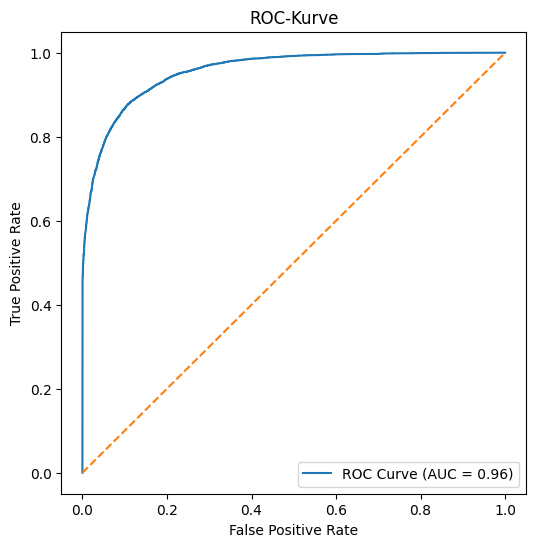

In [7]:
# Nach dem bestehenden Code für die Konfusionsmatrix

# ROC Curve und AUC
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Wahrscheinlichkeiten für die positive Klasse berechnen
y_proba = final_model.predict_proba(X_test_processed)[:, 1]

# ROC Kurve und AUC berechnen
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)


# Plot der ROC-Kurve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # Diagonale
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-Kurve")
plt.legend(loc="lower right")
plt.show()



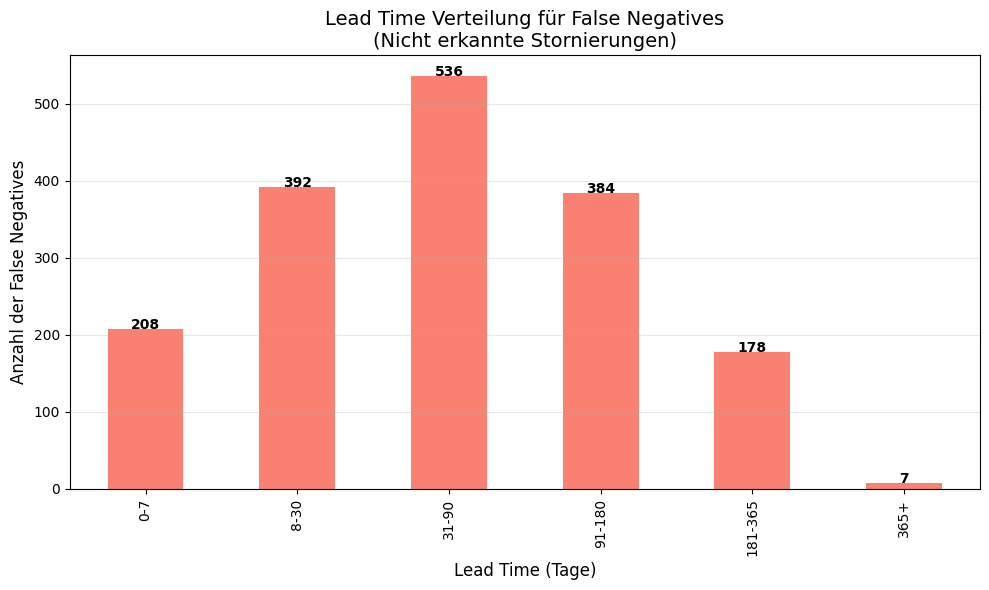

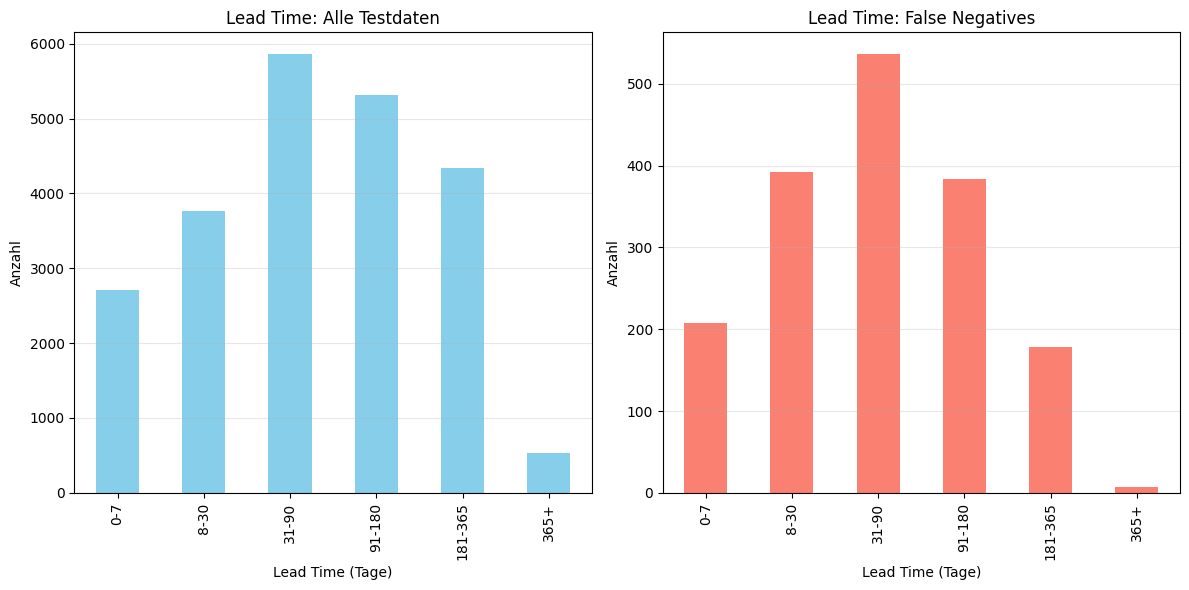

Anzahl der False Negatives: 1771
Durchschnittliche Lead Time bei False Negatives: 75.7 Tage
Median Lead Time bei False Negatives: 51.0 Tage
Min/Max Lead Time bei False Negatives: 0/479 Tage


In [8]:
# Identifiziere die False Negatives (Vorhergesagt als nicht storniert, aber tatsächlich storniert)
false_negatives_idx = np.where((y_test == 1) & (y_pred == 0))[0]

# Originaldaten ohne Preprocessing für die False Negatives extrahieren
# (Wir müssen auf die ursprünglichen Daten zurückgreifen, bevor sie transformiert wurden)
X_test_reset = X_test.reset_index(drop=True)
false_negatives = X_test_reset.iloc[false_negatives_idx]

# Lead Time für die False Negatives extrahieren
fn_lead_times = false_negatives['lead_time']

# Histogramm erstellen (Binning der Lead Times für bessere Übersicht)
bins = [0, 7, 30, 90, 180, 365, np.max(fn_lead_times) + 1]
bin_labels = ['0-7', '8-30', '31-90', '91-180', '181-365', '365+']
fn_lead_time_binned = pd.cut(fn_lead_times, bins=bins, labels=bin_labels)
lead_time_counts = fn_lead_time_binned.value_counts().sort_index()

# Barchart für die Lead Time der False Negatives
plt.figure(figsize=(10, 6))
ax = lead_time_counts.plot(kind='bar', color='salmon')
plt.title('Lead Time Verteilung für False Negatives\n(Nicht erkannte Stornierungen)', fontsize=14)
plt.xlabel('Lead Time (Tage)', fontsize=12)
plt.ylabel('Anzahl der False Negatives', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Anzeigen der Werte über den Balken
for i, v in enumerate(lead_time_counts):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Zusätzlich: Vergleichsdiagramm mit prozentualer Verteilung
plt.figure(figsize=(12, 6))

# Overall lead_time distribution (für alle Test-Daten)
plt.subplot(1, 2, 1)
all_lead_time_binned = pd.cut(X_test['lead_time'], bins=bins, labels=bin_labels)
all_lead_time_counts = all_lead_time_binned.value_counts().sort_index()
all_lead_time_counts.plot(kind='bar', color='skyblue')
plt.title('Lead Time: Alle Testdaten', fontsize=12)
plt.xlabel('Lead Time (Tage)')
plt.ylabel('Anzahl')
plt.grid(axis='y', alpha=0.3)

# False Negatives lead_time distribution
plt.subplot(1, 2, 2)
lead_time_counts.plot(kind='bar', color='salmon')
plt.title('Lead Time: False Negatives', fontsize=12)
plt.xlabel('Lead Time (Tage)')
plt.ylabel('Anzahl')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiken zu den Lead Times der False Negatives ausgeben
print(f"Anzahl der False Negatives: {len(fn_lead_times)}")
print(f"Durchschnittliche Lead Time bei False Negatives: {fn_lead_times.mean():.1f} Tage")
print(f"Median Lead Time bei False Negatives: {fn_lead_times.median():.1f} Tage")
print(f"Min/Max Lead Time bei False Negatives: {fn_lead_times.min()}/{fn_lead_times.max()} Tage")

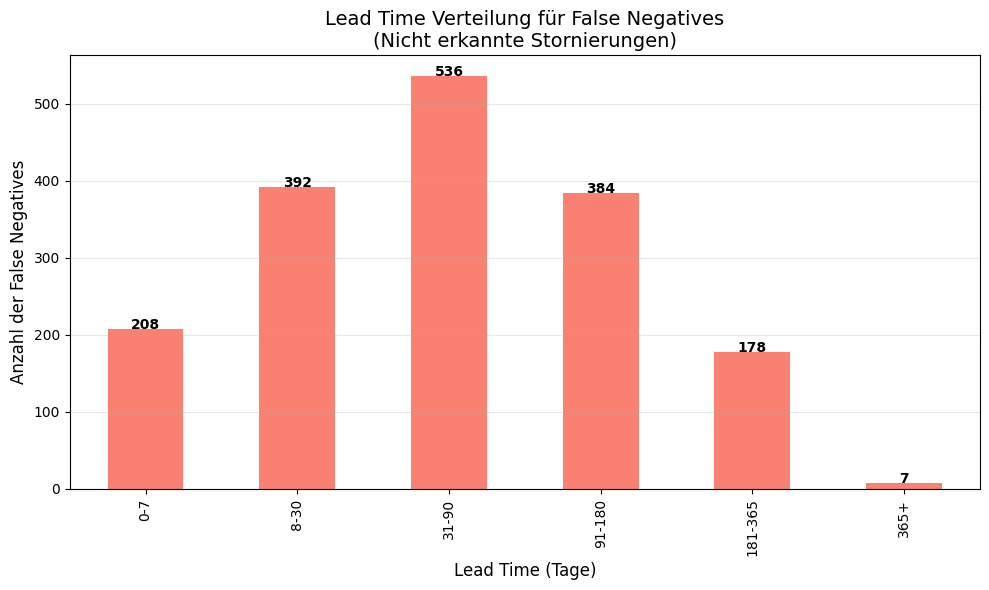

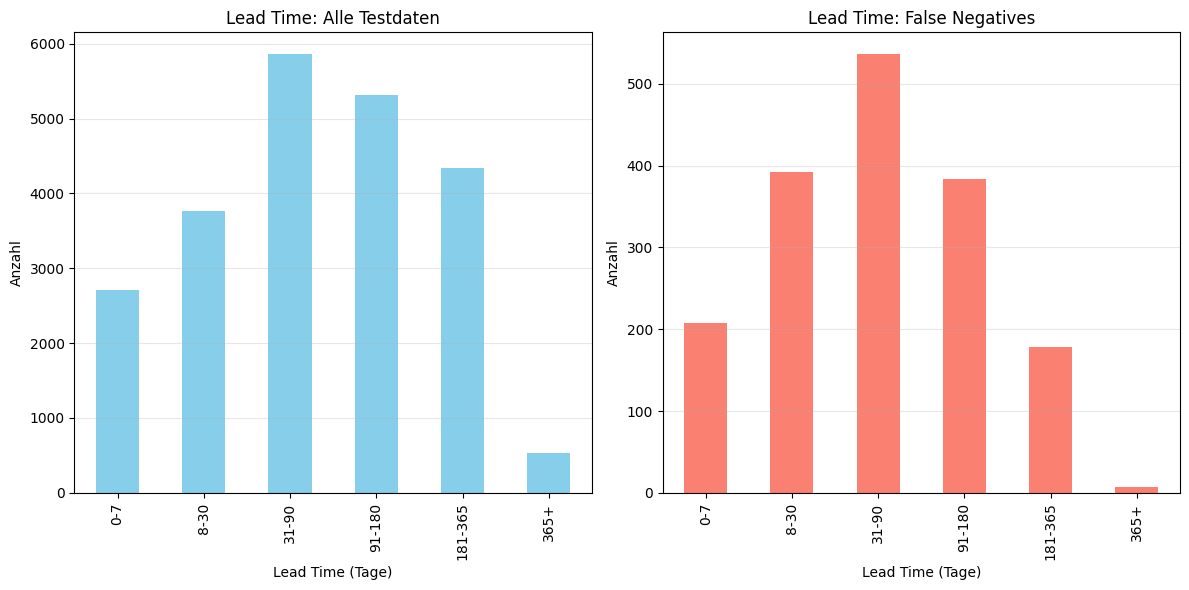

Anzahl der False Negatives: 1771
Durchschnittliche Lead Time bei False Negatives: 75.7 Tage
Median Lead Time bei False Negatives: 51.0 Tage
Min/Max Lead Time bei False Negatives: 0/479 Tage


In [ ]:
# Identifiziere die False Negatives (Vorhergesagt als nicht storniert, aber tatsächlich storniert)
false_negatives_idx = np.where((y_test == 1) & (y_pred == 0))[0]

# Originaldaten ohne Preprocessing für die False Negatives extrahieren
# (Wir müssen auf die ursprünglichen Daten zurückgreifen, bevor sie transformiert wurden)
X_test_reset = X_test.reset_index(drop=True)
false_negatives = X_test_reset.iloc[false_negatives_idx]

# Lead Time für die False Negatives extrahieren
fn_lead_times = false_negatives['lead_time']

# Histogramm erstellen (Binning der Lead Times für bessere Übersicht)
bins = [0, 7, 30, 90, 180, 365, np.max(fn_lead_times) + 1]
bin_labels = ['0-7', '8-30', '31-90', '91-180', '181-365', '365+']
fn_lead_time_binned = pd.cut(fn_lead_times, bins=bins, labels=bin_labels)
lead_time_counts = fn_lead_time_binned.value_counts().sort_index()

# Barchart für die Lead Time der False Negatives
plt.figure(figsize=(10, 6))
ax = lead_time_counts.plot(kind='bar', color='salmon')
plt.title('Lead Time Verteilung für False Negatives\n(Nicht erkannte Stornierungen)', fontsize=14)
plt.xlabel('Lead Time (Tage)', fontsize=12)
plt.ylabel('Anzahl der False Negatives', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Anzeigen der Werte über den Balken
for i, v in enumerate(lead_time_counts):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Zusätzlich: Vergleichsdiagramm mit prozentualer Verteilung
plt.figure(figsize=(12, 6))

# Overall lead_time distribution (für alle Test-Daten)
plt.subplot(1, 2, 1)
all_lead_time_binned = pd.cut(X_test['lead_time'], bins=bins, labels=bin_labels)
all_lead_time_counts = all_lead_time_binned.value_counts().sort_index()
all_lead_time_counts.plot(kind='bar', color='skyblue')
plt.title('Lead Time: Alle Testdaten', fontsize=12)
plt.xlabel('Lead Time (Tage)')
plt.ylabel('Anzahl')
plt.grid(axis='y', alpha=0.3)

# False Negatives lead_time distribution
plt.subplot(1, 2, 2)
lead_time_counts.plot(kind='bar', color='salmon')
plt.title('Lead Time: False Negatives', fontsize=12)
plt.xlabel('Lead Time (Tage)')
plt.ylabel('Anzahl')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Statistiken zu den Lead Times der False Negatives ausgeben
print(f"Anzahl der False Negatives: {len(fn_lead_times)}")
print(f"Durchschnittliche Lead Time bei False Negatives: {fn_lead_times.mean():.1f} Tage")
print(f"Median Lead Time bei False Negatives: {fn_lead_times.median():.1f} Tage")
print(f"Min/Max Lead Time bei False Negatives: {fn_lead_times.min()}/{fn_lead_times.max()} Tage")